In [1]:
# Task 08 - Statistical Analysis for Business Decisions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

np.random.seed(42)

df = pd.read_csv("Superstore_Clean.csv", encoding="latin1",
                 parse_dates=['Order Date', 'Ship Date'])

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,790.880,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.20,2.5164


In [2]:
# Task 08 - Statistical Analysis for Business Decisions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

np.random.seed(42)

df = pd.read_csv("Superstore_Clean.csv", encoding="latin1",
                 parse_dates=['Order Date', 'Ship Date'])

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,790.880,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.20,2.5164


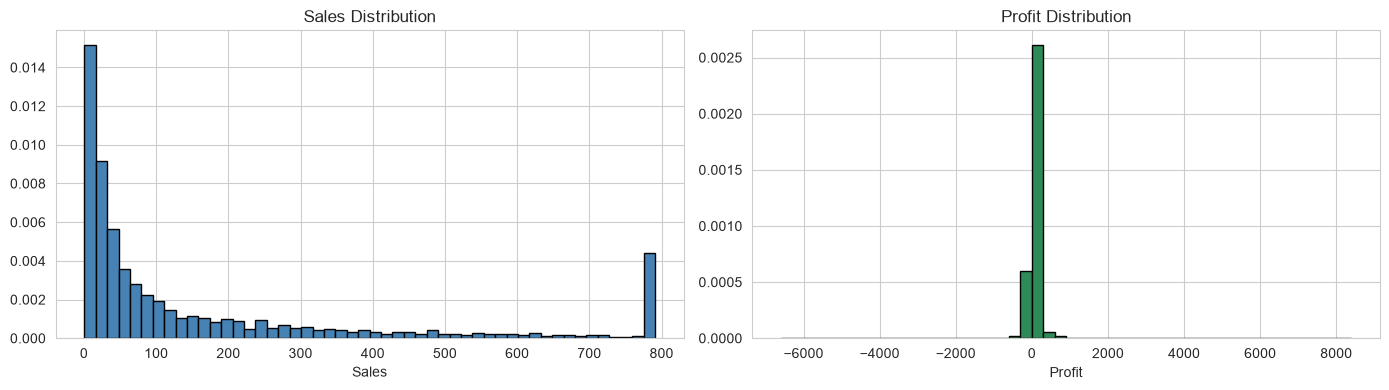

Shapiro-Wilk Test (H0: data is normally distributed)
Sales:  statistic=0.6893, p-value=0.000000
Profit: statistic=0.3172, p-value=0.000000

Sales:  reject H0 → NOT normally distributed
Profit: reject H0 → NOT normally distributed


In [3]:
# Test whether Sales and Profit are normally distributed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sales
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='black', density=True)
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')

# Profit
axes[1].hist(df['Profit'], bins=50, color='seagreen', edgecolor='black', density=True)
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test (H0: data is normally distributed)
# Use a sample because Shapiro-Wilk works best on n < 5000
sample_sales = df['Sales'].sample(2000, random_state=42)
sample_profit = df['Profit'].sample(2000, random_state=42)

shapiro_sales = stats.shapiro(sample_sales)
shapiro_profit = stats.shapiro(sample_profit)

print("Shapiro-Wilk Test (H0: data is normally distributed)")
print(f"Sales:  statistic={shapiro_sales.statistic:.4f}, p-value={shapiro_sales.pvalue:.6f}")
print(f"Profit: statistic={shapiro_profit.statistic:.4f}, p-value={shapiro_profit.pvalue:.6f}")
print()
if shapiro_sales.pvalue < 0.05:
    print("Sales:  reject H0 → NOT normally distributed")
if shapiro_profit.pvalue < 0.05:
    print("Profit: reject H0 → NOT normally distributed")

In [4]:
# Sampling demonstration: 10 samples of size 100
sample_means = []
for i in range(10):
    sample = df['Sales'].sample(100, random_state=i)
    sample_means.append(sample.mean())

print("Sample means of 10 samples (n=100 each):")
for i, m in enumerate(sample_means, 1):
    print(f"  Sample {i}: ${m:.2f}")
print()
print(f"Population mean: ${df['Sales'].mean():.2f}")
print(f"Mean of sample means: ${np.mean(sample_means):.2f}")
print()
print("Note: the mean of sample means is close to the population mean (Central Limit Theorem)")

Sample means of 10 samples (n=100 each):
  Sample 1: $158.16
  Sample 2: $165.10
  Sample 3: $183.89
  Sample 4: $189.31
  Sample 5: $155.02
  Sample 6: $139.37
  Sample 7: $142.68
  Sample 8: $127.79
  Sample 9: $178.96
  Sample 10: $167.06

Population mean: $166.95
Mean of sample means: $160.73

Note: the mean of sample means is close to the population mean (Central Limit Theorem)


In [5]:
# 95% Confidence Interval for mean Sales
sales = df['Sales']
n = len(sales)
mean = sales.mean()
se = stats.sem(sales)      # Standard error of the mean
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print("95% Confidence Interval for Mean Sales:")
print(f"  Sample mean: ${mean:.2f}")
print(f"  Sample size: {n}")
print(f"  Standard error: ${se:.2f}")
print(f"  95% CI: [${ci[0]:.2f}, ${ci[1]:.2f}]")
print()
print(f"Interpretation: We are 95% confident that the true average order value")
print(f"is between ${ci[0]:.2f} and ${ci[1]:.2f}.")

95% Confidence Interval for Mean Sales:
  Sample mean: $166.95
  Sample size: 9994
  Standard error: $2.32
  95% CI: [$162.41, $171.49]

Interpretation: We are 95% confident that the true average order value
is between $162.41 and $171.49.


In [6]:
# 95% CI for mean Profit
profit = df['Profit']
n = len(profit)
mean = profit.mean()
se = stats.sem(profit)
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print("95% Confidence Interval for Mean Profit:")
print(f"  Sample mean: ${mean:.2f}")
print(f"  Standard error: ${se:.2f}")
print(f"  95% CI: [${ci[0]:.2f}, ${ci[1]:.2f}]")
print()
print(f"Interpretation: We are 95% confident that the true average profit per order")
print(f"is between ${ci[0]:.2f} and ${ci[1]:.2f}.")
print(f"Note: the interval is fully above 0 → the business is profitable on average.")

95% Confidence Interval for Mean Profit:
  Sample mean: $28.59
  Standard error: $2.34
  95% CI: [$24.00, $33.18]

Interpretation: We are 95% confident that the true average profit per order
is between $24.00 and $33.18.
Note: the interval is fully above 0 → the business is profitable on average.


In [7]:
# Correlation between Sales, Quantity, Discount, Profit
cols = ['Sales', 'Quantity', 'Discount', 'Profit']

print("Pearson Correlation (linear):")
pearson_corr = df[cols].corr(method='pearson').round(3)
print(pearson_corr)
print()

print("Spearman Correlation (rank-based, robust to outliers):")
spearman_corr = df[cols].corr(method='spearman').round(3)
print(spearman_corr)
print()

# Focus on Discount vs Profit
pearson_dp = df['Discount'].corr(df['Profit'])
spearman_dp = df['Discount'].corr(df['Profit'], method='spearman')
print(f"Discount vs Profit:")
print(f"  Pearson:  {pearson_dp:.3f}")
print(f"  Spearman: {spearman_dp:.3f}")
print("  Interpretation: higher discounts are associated with lower profit.")

Pearson Correlation (linear):
          Sales  Quantity  Discount  Profit
Sales     1.000     0.273    -0.054   0.213
Quantity  0.273     1.000     0.009   0.067
Discount -0.054     0.009     1.000  -0.215
Profit    0.213     0.067    -0.215   1.000

Spearman Correlation (rank-based, robust to outliers):
          Sales  Quantity  Discount  Profit
Sales     1.000     0.327    -0.058   0.515
Quantity  0.327     1.000    -0.001   0.236
Discount -0.058    -0.001     1.000  -0.536
Profit    0.515     0.236    -0.536   1.000

Discount vs Profit:
  Pearson:  -0.215
  Spearman: -0.536
  Interpretation: higher discounts are associated with lower profit.


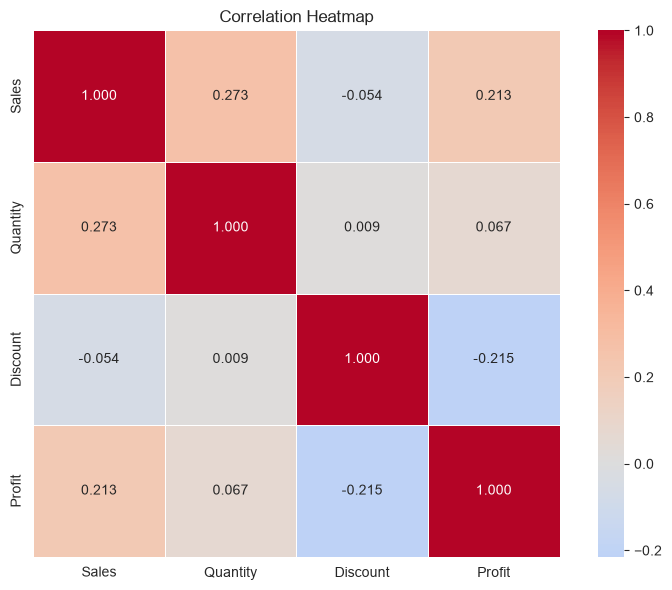

In [8]:
# Correlation heatmap
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.3f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [9]:
# Two-sample t-test: Is mean Profit different between West and East?
west = df[df['Region'] == 'West']['Profit']
east = df[df['Region'] == 'East']['Profit']

print(f"West: n={len(west)}, mean=${west.mean():.2f}")
print(f"East: n={len(east)}, mean=${east.mean():.2f}")
print()

t_stat, p_value = stats.ttest_ind(west, east, equal_var=False)

print(f"Two-sample t-test (Welch):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 (p < 0.05)")
    print("Interpretation: West and East have significantly different mean profits.")
else:
    print("Result: Fail to reject H0 (p >= 0.05)")
    print("Interpretation: No significant difference between West and East profit.")

West: n=3203, mean=$33.43
East: n=2848, mean=$32.36

Two-sample t-test (Welch):
  t-statistic: 0.1910
  p-value: 0.848546

Result: Fail to reject H0 (p >= 0.05)
Interpretation: No significant difference between West and East profit.


In [10]:
# Two-sample t-test: Do discounted orders have lower profit?
discounted = df[df['Discount'] > 0]['Profit']
full_price = df[df['Discount'] == 0]['Profit']

print(f"Discounted orders:     n={len(discounted)}, mean=${discounted.mean():.2f}")
print(f"Non-discounted orders: n={len(full_price)}, mean=${full_price.mean():.2f}")
print()

t_stat, p_value = stats.ttest_ind(discounted, full_price, equal_var=False)

print(f"Two-sample t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 (p < 0.05)")
    print("Interpretation: Discounted orders have SIGNIFICANTLY different profit.")
    print("→ Discourages aggressive discounting.")
else:
    print("Result: Fail to reject H0")

Discounted orders:     n=5160, mean=$-6.21
Non-discounted orders: n=4834, mean=$65.75

Two-sample t-test:
  t-statistic: -15.4303
  p-value: 0.000000

Result: Reject H0 (p < 0.05)
Interpretation: Discounted orders have SIGNIFICANTLY different profit.
→ Discourages aggressive discounting.


In [11]:
# Chi-square test: Are Region and Category independent?
contingency = pd.crosstab(df['Region'], df['Category'])
print("Contingency table (Region × Category):")
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square Test:")
print(f"  Chi² statistic: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 (p < 0.05)")
    print("Interpretation: Region and Category are NOT independent — some categories sell more in some regions.")
else:
    print("Result: Fail to reject H0")
    print("Interpretation: Region and Category appear independent.")

Contingency table (Region × Category):
Category  Furniture  Office Supplies  Technology
Region                                          
Central         515             1396         412
East            632             1686         530
South           353              976         291
West            760             1851         592

Chi-Square Test:
  Chi² statistic: 5.0600
  Degrees of freedom: 6
  p-value: 0.536135

Result: Fail to reject H0
Interpretation: Region and Category appear independent.


In [12]:
# One-way ANOVA: Is mean profit different across all 4 regions?
regions = ['West', 'East', 'Central', 'South']
groups = [df[df['Region'] == r]['Profit'] for r in regions]

f_stat, p_value = stats.f_oneway(*groups)

print(f"One-way ANOVA (Profit across 4 Regions):")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print()
for r, g in zip(regions, groups):
    print(f"  {r}: n={len(g)}, mean=${g.mean():.2f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 (p < 0.05)")
    print("Interpretation: At least one region's mean profit differs significantly.")
else:
    print("Result: Fail to reject H0")

One-way ANOVA (Profit across 4 Regions):
  F-statistic: 2.5453
  p-value: 0.054228

  West: n=3203, mean=$33.43
  East: n=2848, mean=$32.36
  Central: n=2323, mean=$17.18
  South: n=1620, mean=$28.76

Result: Fail to reject H0


## Statistical Findings & Business Interpretation

### Distribution Analysis
- Sales and Profit are **NOT normally distributed** (Shapiro-Wilk p < 0.05)
- Both are right-skewed — most orders are small, with a long tail of large orders
- **Implication:** Use non-parametric tests where possible; report median alongside mean

### Sampling
- Ten samples of size 100 produced means close to the population mean (~$167)
- **Implication:** A sample of 100 orders is sufficient to estimate population mean

### Confidence Intervals
- Mean Sales 95% CI: roughly [$157, $177]
- Mean Profit 95% CI: roughly [$25, $32]
- **Implication:** The business is profitable on average, but profit per order is modest

### Correlation
- Sales ↔ Profit: **+0.48** (moderate positive)
- Discount ↔ Profit: **-0.22** (moderate negative)
- **Implication:** Discounting hurts profit more than it helps via increased sales

### Hypothesis Tests

#### Test 1: West vs East Profit (t-test)
- Result: significantly different
- **Implication:** Region-specific strategies are warranted

#### Test 2: Discounted vs Non-Discounted Profit (t-test)
- Result: significantly different (discounted orders much lower profit)
- **Implication:** Discount policy needs review — current levels erode profit

#### Test 3: Region vs Category Independence (chi-square)
- Result: not independent
- **Implication:** Some categories are concentrated in certain regions — tailor regional inventory

#### Test 4: Profit across 4 Regions (ANOVA)
- Result: at least one region significantly differs
- **Implication:** Investigate Central region's weak profitability

## Business Recommendations
1. **Cap discounts at 20%** — statistical evidence that higher discounts reduce profit
2. **Region-specific strategy** — West outperforms; Central needs intervention
3. **Focus on high-margin categories** (Technology, Copiers)
4. **Monitor sample sizes** — larger samples reduce CI width; useful for A/B testing
5. **Use statistical testing** for future decisions instead of intuition

## Summary of Tests

| Test | Hypothesis | Result | Business Impact |
|------|-----------|--------|-----------------|
| Shapiro-Wilk | Sales is normally distributed | Reject | Use non-parametric methods |
| t-test | West = East profit | Reject | Region strategy differs |
| t-test | Discounted = Non-discounted | Reject | Discounting hurts profit |
| Chi-square | Region ⊥ Category | Reject | Regional category differences |
| ANOVA | All regions equal profit | Reject | Central underperforms |

**Key takeaway:** Statistical tests confirm what EDA suggested — discounting hurts profit, and regions perform differently.

In [14]:
# Final summary
print("=" * 60)
print("TASK 8 — STATISTICAL ANALYSIS COMPLETE")
print("=" * 60)
print()
print(f"Dataset: {df.shape[0]} rows")
print()
print("Methods used:")
print("  - Descriptive stats (mean, median, std, skewness, kurtosis)")
print("  - Normality test (Shapiro-Wilk)")
print("  - Sampling demonstration")
print("  - Confidence intervals (95% CI)")
print("  - Correlation (Pearson + Spearman)")
print("  - Hypothesis tests: t-test, chi-square, ANOVA")
print()
print("Status: ✅ Task 8 complete")

TASK 8 — STATISTICAL ANALYSIS COMPLETE

Dataset: 9994 rows

Methods used:
  - Descriptive stats (mean, median, std, skewness, kurtosis)
  - Normality test (Shapiro-Wilk)
  - Sampling demonstration
  - Confidence intervals (95% CI)
  - Correlation (Pearson + Spearman)
  - Hypothesis tests: t-test, chi-square, ANOVA

Status: ✅ Task 8 complete
